In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [30]:
df = pd.read_csv("titanic_toy.csv")

In [31]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [32]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [33]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [34]:
X = df.drop("Survived", axis =1)
y = df["Survived"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
X_train.head()

,Age,Fare,Family
331,45.5,28.5000,0
733,23.0,13.0000,0
382,32.0,7.9250,0
704,26.0,7.8542,1
813,6.0,31.2750,6


In [37]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [38]:
X_train["age_99"] = X_train["Age"].fillna(99)
X_train["age_minus1"] = X_train["Age"].fillna(-1)

X_train["fare_999"] = X_train["Fare"].fillna(999)
X_train["fare_minus1"] = X_train["Fare"].fillna(-1)

In [39]:
X_train.sample(5)

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
349,42.0,8.6625,0,42.0,42.0,8.6625,8.6625
847,35.0,7.8958,0,35.0,35.0,7.8958,7.8958
293,24.0,8.8500,0,24.0,24.0,8.8500,8.8500
64,NaN,27.7208,0,99.0,-1.0,27.7208,27.7208
202,34.0,6.4958,0,34.0,34.0,6.4958,6.4958


In [40]:
print("Original age variance: ", X_train["Age"].var())
print("age variance after 99 impute: ", X_train["age_99"].var())
print("age variance after -1 impute: ", X_train["age_minus1"].var())

Original age variance:  210.2517072477435
age variance after 99 impute:  932.9665366701432
age variance after -1 impute:  315.9955036260055


In [41]:
print("Original fare variance: ", X_train["Fare"].var())
print("fare variance after 999 impute: ", X_train["fare_999"].var())
print("fare variance after -1 impute: ", X_train["fare_minus1"].var())

Original fare variance:  2761.0314349486343
fare variance after 999 impute:  47525.470595360035
fare variance after -1 impute:  2675.2394049177024


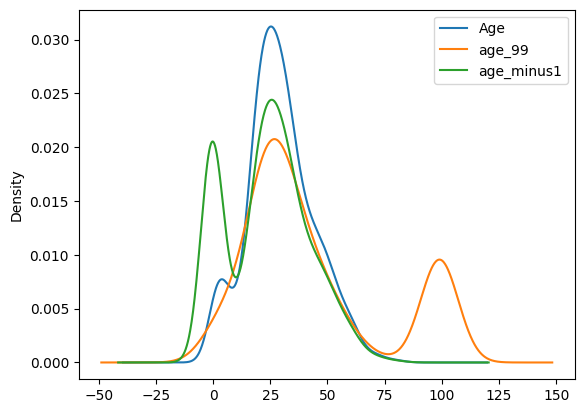

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train["Age"].plot(kind="kde", ax=ax)
X_train["age_99"].plot(kind="kde", ax=ax)
X_train["age_minus1"].plot(kind="kde", ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc="best")
plt.show()

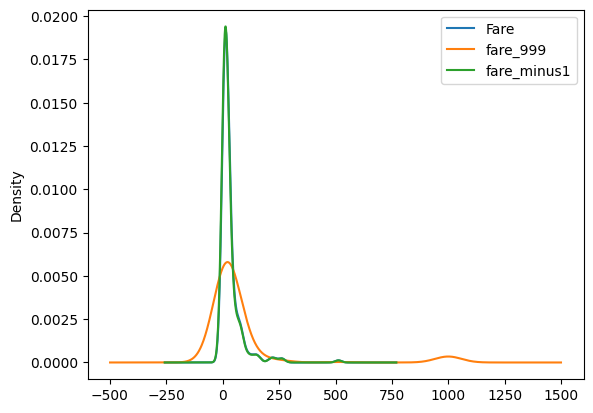

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train["Fare"].plot(kind="kde", ax=ax)
X_train["fare_999"].plot(kind="kde", ax=ax)
X_train["fare_minus1"].plot(kind="kde", ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc="best")
plt.show()

In [44]:
X_train.cov()

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,130.495777,69.137162
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,16.878492,17.684447
age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-255.051165,-101.137070
age_minus1,210.251707,135.785804,-5.034556,-166.460682,315.995504,262.712284,124.270305
fare_999,130.495777,2761.031435,16.878492,-255.051165,262.712284,47525.470595,1063.944817
fare_minus1,69.137162,2761.031435,17.684447,-101.137070,124.270305,1063.944817,2675.239405


In [45]:
X_train.corr()

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.039967,0.085422
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.046016,0.203212
age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.038303,-0.064017
age_minus1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.067792,0.135159
fare_999,0.039967,1.000000,0.046016,-0.038303,0.067792,1.000000,0.094357
fare_minus1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.094357,1.000000


<Axes: >

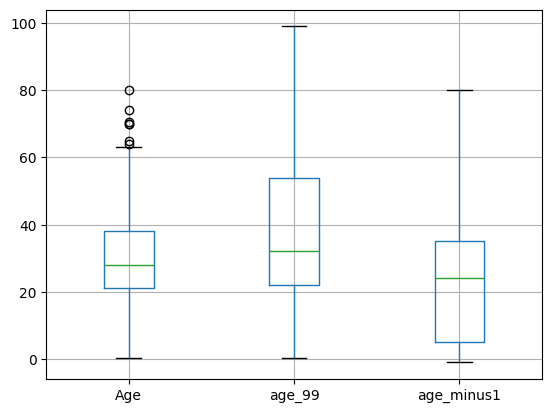

In [46]:
X_train[["Age", "age_99", "age_minus1"]].boxplot()

# Using Sklearn

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
imputer1 = SimpleImputer(strategy="constant", fill_value=99)
imputer2 = SimpleImputer(strategy="constant", fill_value=999)

In [49]:
trf = ColumnTransformer([
    ("impute1", imputer1, ["Age"]),
    ("impute2", imputer2, ["Fare"])
], remainder="passthrough")

In [50]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('impute1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('impute2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [51]:
trf.named_transformers_["impute1"].statistics_

array([99.])

In [52]:
trf.named_transformers_["impute2"].statistics_

array([999.])

In [53]:
X_train_trf = trf.transform(X_train)
X_test_trf = trf.transform(X_test)

In [54]:
X_train_trf

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    , 999.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]])